In [29]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from datetime import timedelta
from pathlib import Path
from mlforecast import MLForecast
import seaborn as sns
import matplotlib.pyplot as plt
import config
from src.data.reader import read_parquet_pl
import matplotlib.dates as mdates

pd.set_option("display.max_columns", None)

In [30]:
import importlib
import config
import config.features
importlib.reload(config.features)
importlib.reload(config)

<module 'config' from '/bi/workspace/Sandbox/forecast-tfm/notebooks/../config/__init__.py'>

In [31]:
!ls ../data/processed/

dataset_level_01_daily_w1y_cum14_total.parquet
dataset_level_01_daily_w1y_cum21_total.parquet
dataset_level_01_daily_w1y_cum28_total.parquet
dataset_level_01_daily_w1y_cum35_total.parquet
dataset_level_01_daily_w1y_cum365_total.parquet
dataset_level_01_daily_w1y_cum42_total.parquet
dataset_level_01_daily_w1y_cum7_total.parquet
dataset_level_01_daily_w1y_sales_total.parquet
dataset_level_01_daily_w2y_cum14_total.parquet
dataset_level_01_daily_w2y_cum21_total.parquet
dataset_level_01_daily_w2y_cum28_total.parquet
dataset_level_01_daily_w2y_cum35_total.parquet
dataset_level_01_daily_w2y_cum365_total.parquet
dataset_level_01_daily_w2y_cum42_total.parquet
dataset_level_01_daily_w2y_cum7_total.parquet
dataset_level_01_daily_w2y_sales_total.parquet
dataset_level_01_daily_w3y_cum14_total.parquet
dataset_level_01_daily_w3y_cum21_total.parquet
dataset_level_01_daily_w3y_cum28_total.parquet
dataset_level_01_daily_w3y_cum35_total.parquet
dataset_level_01_daily_w3y_cum365_total.parquet
dataset_leve

In [32]:
!ls ../artifacts/models/

mlf_level_01_daily_w1y_cum14_total
mlf_level_01_daily_w1y_cum21_total
mlf_level_01_daily_w1y_cum28_total
mlf_level_01_daily_w1y_cum35_total
mlf_level_01_daily_w1y_cum42_total
mlf_level_01_daily_w1y_cum7_total
mlf_level_01_daily_w2y_cum14_total
mlf_level_01_daily_w2y_cum21_total
mlf_level_01_daily_w2y_cum28_total
mlf_level_01_daily_w2y_cum35_total
mlf_level_01_daily_w2y_cum42_total
mlf_level_01_daily_w2y_cum7_total
mlf_level_01_daily_w2y_sales_total
mlf_level_01_daily_w3y_cum14_total
mlf_level_01_daily_w3y_cum21_total
mlf_level_01_daily_w3y_cum28_total
mlf_level_01_daily_w3y_cum35_total
mlf_level_01_daily_w3y_cum365_total
mlf_level_01_daily_w3y_cum42_total
mlf_level_01_daily_w3y_cum7_total
mlf_level_01_daily_w3y_sales_total
mlf_level_01_daily_wmax_cum14_total
mlf_level_01_daily_wmax_cum21_total
mlf_level_01_daily_wmax_cum28_total
mlf_level_01_daily_wmax_cum35_total
mlf_level_01_daily_wmax_cum365_total
mlf_level_01_daily_wmax_cum42_total
mlf_level_01_daily_wmax_cum7_total
mlf_level_01_da

# Modelo

# Cargar Modelo

In [33]:
# ── Elige el nivel a estudiar ──────────────────────────────────────────────
LEVEL_NAME    = "item_store"  # total | state | cat | dept | store | state_cat | ...
GRAIN         = "daily"       # "daily" | "weekly"
WINDOW        = "w1y"         # "w1y" | "w2y" | "w3y" | "w4y" | "wmax"
HORIZON_TYPE  = "cum28"       # "cum7"|"cum14"|"cum21"|"cum28"|"cum35"|"cum42"|"cum365"|"sales"

# ── Rutas ──────────────────────────────────────────────────────────────────
_parquets = sorted(Path("../data/processed").glob(
    f"dataset_level_*_{GRAIN}_{WINDOW}_{HORIZON_TYPE}_{LEVEL_NAME}.parquet"))
_models   = sorted(Path("../artifacts/models").glob(
    f"mlf_*_{GRAIN}_{WINDOW}_{HORIZON_TYPE}_{LEVEL_NAME}"))

if not _parquets:
    available = sorted(Path("../data/processed").glob(f"dataset_level_*_{LEVEL_NAME}.parquet"))
    raise FileNotFoundError(
        f"No hay parquet {GRAIN!r}/{WINDOW!r}/{HORIZON_TYPE!r} para '{LEVEL_NAME}'.\n"
        f"Disponibles: {[p.name for p in available]}"
    )
if not _models:
    available = sorted(Path("../artifacts/models").glob(f"mlf_*_{LEVEL_NAME}"))
    raise FileNotFoundError(
        f"No hay modelo {GRAIN!r}/{WINDOW!r}/{HORIZON_TYPE!r} para '{LEVEL_NAME}'.\n"
        f"Disponibles: {[m.name for m in available]}"
    )

file      = _parquets[0]
model_dir = _models[0]
print(f"Parquet : {file.name}")
print(f"Modelo  : {model_dir.name}")

Parquet : dataset_level_12_daily_w1y_cum28_item_store.parquet
Modelo  : mlf_level_12_daily_w1y_cum28_item_store


In [34]:
import re as _re

# ── Carga y split temporal ─────────────────────────────────────────────────
_raw = read_parquet_pl(file).rename({"agg_id": "unique_id", "date": "ds", "sales": "y"})

# Para cumN: predecir h=N rolling (un acumulado por cada día del período de validación)
# Para sales: h=max_horizonte, igual que antes
_cum_n      = int(_re.search(r"\d+", HORIZON_TYPE).group()) if HORIZON_TYPE.startswith("cum") else None
horizon_val = _cum_n if _cum_n is not None else max(config.HORIZON[GRAIN])
h_predict   = horizon_val  # antes era 1 para cumN; ahora generamos N puntos rolling

delta_days = horizon_val * 7 if GRAIN == "weekly" else horizon_val
cutoff     = _raw["ds"].max() - timedelta(days=delta_days)
valid_pl   = _raw.filter(pl.col("ds") > cutoff)

# ── Exog futuras (igual que en entrenamiento) ──────────────────────────────
exog_cols   = [config.PRICE_LAG_COL[GRAIN]] + config.EXOG_COLS
avail_exog  = [c for c in exog_cols if c in valid_pl.columns]
future_exog = valid_pl.select(["unique_id", "ds"] + avail_exog).to_pandas()

In [35]:
# ── Predicción ─────────────────────────────────────────────────────────────
fcst = MLForecast.load(str(model_dir))

future_skeleton  = fcst.make_future_dataframe(h=h_predict)
future_exog_full = future_skeleton.merge(future_exog, on=["unique_id", "ds"], how="left")

preds_df = fcst.predict(h=h_predict, X_df=future_exog_full)

# ── df con predicciones ───────────────────────────────────────────────────
dim_cols = [c for c in valid_pl.columns if c.endswith("_id") and c != "unique_id"]

df = (
    valid_pl.select(["unique_id", "ds", "y"] + dim_cols)
    .to_pandas()
    .rename(columns={"unique_id": "agg_id", "ds": "date", "y": "sales"})
    .merge(
        preds_df[["unique_id", "ds", "lgb"]].rename(
            columns={"unique_id": "agg_id", "ds": "date", "lgb": "forecast"}
        ),
        on=["agg_id", "date"],
    )
)

df["sales"] = df["sales"].round().astype("int64")
df["forecast"] = df["forecast"].round().astype("int64")

df["error"]     = df["sales"] - df["forecast"]
df["abs_error"] = df["error"].abs()

ordered_cols = [
    "agg_id", "state_id", "store_id", "cat_id", "dept_id", "item_id",
    "date", "sales", "forecast", "error", "abs_error",
]
df = df[[c for c in ordered_cols if c in df.columns]]

df.head()

/bi/workspace/Sandbox/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_mean.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
/bi/workspace/Sandbox/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_mean.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
/bi/workspace/Sandbox/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_mean.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
/bi/workspace/Sandbox/forecast-tfm/.venv/lib/python3.13/site-packages/mlforecast/core.py:625: UserWarning: Found null values in price_lag_7, avg_sell_price, price_change, price_vs_mean.
  warnings.warn(f'Found null values in {", 

,agg_id,state_id,store_id,cat_id,dept_id,item_id,date,sales,forecast,error,abs_error
0,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-24,23,27,-4,4
1,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-25,21,29,-8,8
2,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-26,21,28,-7,7
3,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-27,21,27,-6,6
4,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-28,21,27,-6,6


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 853720 entries, 0 to 853719
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   agg_id     853720 non-null  str           
 1   state_id   853720 non-null  str           
 2   store_id   853720 non-null  str           
 3   cat_id     853720 non-null  str           
 4   dept_id    853720 non-null  str           
 5   item_id    853720 non-null  str           
 6   date       853720 non-null  datetime64[ms]
 7   sales      853720 non-null  int64         
 8   forecast   853720 non-null  int64         
 9   error      853720 non-null  int64         
 10  abs_error  853720 non-null  int64         
dtypes: datetime64[ms](1), int64(4), str(6)
memory usage: 130.6 MB


In [37]:
df.value_counts('agg_id')

agg_id
FOODS_1_FOODS_FOODS_1_001_CA_CA_1                28
FOODS_1_FOODS_FOODS_1_001_CA_CA_2                28
FOODS_1_FOODS_FOODS_1_001_CA_CA_3                28
FOODS_1_FOODS_FOODS_1_001_CA_CA_4                28
FOODS_1_FOODS_FOODS_1_001_TX_TX_1                28
                                                 ..
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_516_TX_TX_2    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_516_TX_TX_3    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_516_WI_WI_1    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_516_WI_WI_2    28
HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_516_WI_WI_3    28
Name: count, Length: 30490, dtype: int64

In [38]:
df.value_counts('date')

date
2016-04-24    30490
2016-04-25    30490
2016-04-26    30490
2016-04-27    30490
2016-04-28    30490
2016-04-29    30490
2016-04-30    30490
2016-05-01    30490
2016-05-02    30490
2016-05-03    30490
2016-05-04    30490
2016-05-05    30490
2016-05-06    30490
2016-05-07    30490
2016-05-08    30490
2016-05-09    30490
2016-05-10    30490
2016-05-11    30490
2016-05-12    30490
2016-05-13    30490
2016-05-14    30490
2016-05-15    30490
2016-05-16    30490
2016-05-17    30490
2016-05-18    30490
2016-05-19    30490
2016-05-20    30490
2016-05-21    30490
Name: count, dtype: int64

# Exploracion

In [39]:
def analyze_agg(df: pd.DataFrame, group_by: list[str] | None = None) -> pd.DataFrame:
    if group_by is None:
        group_by = ["agg_id"] + [
            c for c in df.columns
            if c.endswith("_id") and c != "agg_id"
        ]

    def agg_fn(g: pd.DataFrame) -> pd.Series:
        active_mask = g["sales"] > 0
        sales_active = g.loc[active_mask, "sales"]
        sales_dates = g.loc[active_mask, "date"]

        sales_sum = g["sales"].sum()
        error_sum = g["error"].sum()
        abs_error_sum = g["abs_error"].sum()

        first_sale = sales_dates.min() if not sales_dates.empty else pd.NaT
        last_sale = sales_dates.max() if not sales_dates.empty else pd.NaT

        active_periods = int(active_mask.sum())
        available_periods = (
            int((g["date"] >= first_sale).sum()) if pd.notna(first_sale) else 0
        )

        adi = available_periods / active_periods if active_periods else np.nan
        cv2 = (sales_active.std() / sales_active.mean()) ** 2 if active_periods > 1 else np.nan

        return pd.Series({
            "n_obs": len(g),
            "sales_sum": sales_sum,
            "forecast_sum": g["forecast"].sum(),
            "rmse": np.sqrt((g["error"] ** 2).mean()),
            "first_sale": first_sale,
            "last_sale": last_sale,
            "available_periods": available_periods,
            "active_periods": active_periods,
            "avg_sale_when_active": sales_active.mean() if active_periods else np.nan,
            "adi": adi,
            "cv2": cv2,
            "wape": abs_error_sum / abs(sales_sum) if sales_sum else np.nan,
            "bias": -error_sum / abs(sales_sum) if sales_sum else np.nan,
        })

    result = (
        df.groupby(group_by)
        .apply(agg_fn, include_groups=False)
        .reset_index()
    )

    result["demand_type"] = np.select(
        [
            (result["adi"] < 1.32) & (result["cv2"] < 0.49),
            (result["adi"] < 1.32) & (result["cv2"] >= 0.49),
            (result["adi"] >= 1.32) & (result["cv2"] < 0.49),
            (result["adi"] >= 1.32) & (result["cv2"] >= 0.49),
        ],
        ["smooth", "erratic", "intermittent", "lumpy"],
        default="unknown",
    )

    #result["sale_span_days"] = (result["last_sale"] - result["first_sale"]).dt.days
    result['available_ratio'] = result["available_periods"] / result["n_obs"]
    result["active_ratio"] = result["active_periods"] / result["n_obs"]

    return result.sort_values(group_by).reset_index(drop=True)

In [40]:
def plot_agg_id_forecast(df, agg_id=None):
    if agg_id is None:
        agg_id = df["agg_id"].sample(1).iloc[0]

    s = (
        df[df["agg_id"] == agg_id]
        .sort_values("date")
        .copy()
    )

    if s.empty:
        raise ValueError(f"agg_id '{agg_id}' no existe en el df.")

    dates = s["date"].to_numpy()
    sales = s["sales"].to_numpy()
    forecast = s["forecast"].to_numpy()

    meta = s.iloc[0].to_dict()

    dim_info = {
        k: v
        for k, v in meta.items()
        if k.endswith("_id")
        and k != "agg_id"
        and pd.notna(v)
    }

    subtitle = " | ".join(
        f"{k.replace('_id', '')}: {v}"
        for k, v in dim_info.items()
    )

    denom = np.abs(sales).sum()
    wape = np.abs(sales - forecast).sum() / denom if denom else np.nan
    bias = (forecast - sales).sum() / denom if denom else np.nan

    fig, ax = plt.subplots(figsize=(15, 6))

    fig.suptitle(
        f"agg_id: {agg_id} | WAPE: {wape:.1%} | Bias: {bias:.1%}",
        fontsize=13,
    )

    if subtitle:
        ax.set_title(subtitle, fontsize=10)

    ax.plot(
        dates,
        sales,
        marker="o",
        label="Real",
    )

    ax.plot(
        dates,
        forecast,
        marker="o",
        linestyle="--",
        label="Forecast",
    )

    ax.set_ylabel("Ventas")

    ymax = max(sales.max(), forecast.max())
    ax.set_ylim(0, ymax * 1.1 if ymax > 0 else 1)

    ax.legend()
    ax.grid(alpha=0.3)
    
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
    if GRAIN == 'daily':
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [41]:
df_summary = analyze_agg(df)

df_summary.head()

,agg_id,state_id,store_id,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio
0,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,28,291,755,18.334199,2016-04-24,2016-05-18,28,25,11.640000,1.120000,0.439689,1.594502,1.594502,smooth,1.0,0.892857
1,FOODS_1_FOODS_FOODS_1_001_CA_CA_2,CA,CA_2,FOODS,FOODS_1,FOODS_1_001,28,248,863,22.572898,2016-04-24,2016-05-20,28,27,9.185185,1.037037,0.269003,2.479839,2.479839,smooth,1.0,0.964286
2,FOODS_1_FOODS_FOODS_1_001_CA_CA_3,CA,CA_3,FOODS,FOODS_1,FOODS_1_001,28,397,816,16.387059,2016-04-24,2016-05-21,28,28,14.178571,1.000000,0.220733,1.055416,1.055416,smooth,1.0,1.000000
3,FOODS_1_FOODS_FOODS_1_001_CA_CA_4,CA,CA_4,FOODS,FOODS_1,FOODS_1_001,28,90,256,6.170205,2016-04-24,2016-05-18,28,25,3.600000,1.120000,0.141461,1.844444,1.844444,smooth,1.0,0.892857
4,FOODS_1_FOODS_FOODS_1_001_TX_TX_1,TX,TX_1,FOODS,FOODS_1,FOODS_1_001,28,471,361,11.451762,2016-04-24,2016-05-21,28,28,16.821429,1.000000,0.199754,0.602972,-0.233546,smooth,1.0,1.000000


In [42]:
df_summary['bias_abs'] = df_summary['bias'].abs()

df_summary = df_summary.sort_values("wape")
#df_summary = df_summary.dropna()
df_summary.head(10)

,agg_id,state_id,store_id,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio,bias_abs
3285,FOODS_2_FOODS_FOODS_2_114_TX_TX_2,TX,TX_2,FOODS,FOODS_2,FOODS_2_114,28,81,90,1.700840,2016-04-24,2016-05-20,28,27,3.000000,1.037037,0.000000,0.111111,0.111111,smooth,1.0,0.964286,0.111111
28466,HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_314_TX_TX_3,TX,TX_3,HOUSEHOLD,HOUSEHOLD_2,HOUSEHOLD_2_314,28,81,90,1.700840,2016-04-24,2016-05-20,28,27,3.000000,1.037037,0.000000,0.111111,0.111111,smooth,1.0,0.964286,0.111111
15599,HOBBIES_1_HOBBIES_HOBBIES_1_127_WI_WI_3,WI,WI_3,HOBBIES,HOBBIES_1,HOBBIES_1_127,28,239,248,1.426785,2016-04-24,2016-05-21,28,28,8.535714,1.000000,0.026924,0.112971,0.037657,smooth,1.0,1.000000,0.037657
21607,HOUSEHOLD_1_HOUSEHOLD_HOUSEHOLD_1_163_WI_WI_1,WI,WI_1,HOUSEHOLD,HOUSEHOLD_1,HOUSEHOLD_1_163,28,86,87,1.052209,2016-04-24,2016-05-20,28,27,3.185185,1.037037,0.015445,0.127907,0.011628,smooth,1.0,0.964286,0.011628
4845,FOODS_2_FOODS_FOODS_2_270_TX_TX_2,TX,TX_2,FOODS,FOODS_2,FOODS_2_270,28,84,95,0.731925,2016-04-24,2016-05-21,28,28,3.000000,1.000000,0.000000,0.130952,0.130952,smooth,1.0,1.000000,0.130952
4645,FOODS_2_FOODS_FOODS_2_250_TX_TX_2,TX,TX_2,FOODS,FOODS_2,FOODS_2_250,28,125,140,1.700840,2016-04-24,2016-05-20,28,27,4.629630,1.037037,0.036421,0.136000,0.120000,smooth,1.0,0.964286,0.120000
4851,FOODS_2_FOODS_FOODS_2_271_CA_CA_2,CA,CA_2,FOODS,FOODS_2,FOODS_2_271,28,191,205,1.945691,2016-04-24,2016-05-21,28,28,6.821429,1.000000,0.054210,0.146597,0.073298,smooth,1.0,1.000000,0.073298
7709,FOODS_3_FOODS_FOODS_3_158_WI_WI_3,WI,WI_3,FOODS,FOODS_3,FOODS_3_158,28,189,194,2.095914,2016-04-24,2016-05-20,28,27,7.000000,1.037037,0.021978,0.153439,0.026455,smooth,1.0,0.964286,0.026455
29925,HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_460_TX_TX_2,TX,TX_2,HOUSEHOLD,HOUSEHOLD_2,HOUSEHOLD_2_460,28,80,93,1.349603,2016-04-24,2016-05-19,28,26,3.076923,1.076923,0.007800,0.162500,0.162500,smooth,1.0,0.928571,0.162500
19429,HOBBIES_2_HOBBIES_HOBBIES_2_090_WI_WI_3,WI,WI_3,HOBBIES,HOBBIES_2,HOBBIES_2_090,28,128,121,1.017700,2016-04-24,2016-05-21,28,28,4.571429,1.000000,0.026331,0.164062,-0.054688,smooth,1.0,1.000000,0.054688


In [43]:
df_summary.head()

,agg_id,state_id,store_id,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio,bias_abs
3285,FOODS_2_FOODS_FOODS_2_114_TX_TX_2,TX,TX_2,FOODS,FOODS_2,FOODS_2_114,28,81,90,1.700840,2016-04-24,2016-05-20,28,27,3.000000,1.037037,0.000000,0.111111,0.111111,smooth,1.0,0.964286,0.111111
28466,HOUSEHOLD_2_HOUSEHOLD_HOUSEHOLD_2_314_TX_TX_3,TX,TX_3,HOUSEHOLD,HOUSEHOLD_2,HOUSEHOLD_2_314,28,81,90,1.700840,2016-04-24,2016-05-20,28,27,3.000000,1.037037,0.000000,0.111111,0.111111,smooth,1.0,0.964286,0.111111
15599,HOBBIES_1_HOBBIES_HOBBIES_1_127_WI_WI_3,WI,WI_3,HOBBIES,HOBBIES_1,HOBBIES_1_127,28,239,248,1.426785,2016-04-24,2016-05-21,28,28,8.535714,1.000000,0.026924,0.112971,0.037657,smooth,1.0,1.000000,0.037657
21607,HOUSEHOLD_1_HOUSEHOLD_HOUSEHOLD_1_163_WI_WI_1,WI,WI_1,HOUSEHOLD,HOUSEHOLD_1,HOUSEHOLD_1_163,28,86,87,1.052209,2016-04-24,2016-05-20,28,27,3.185185,1.037037,0.015445,0.127907,0.011628,smooth,1.0,0.964286,0.011628
4845,FOODS_2_FOODS_FOODS_2_270_TX_TX_2,TX,TX_2,FOODS,FOODS_2,FOODS_2_270,28,84,95,0.731925,2016-04-24,2016-05-21,28,28,3.000000,1.000000,0.000000,0.130952,0.130952,smooth,1.0,1.000000,0.130952


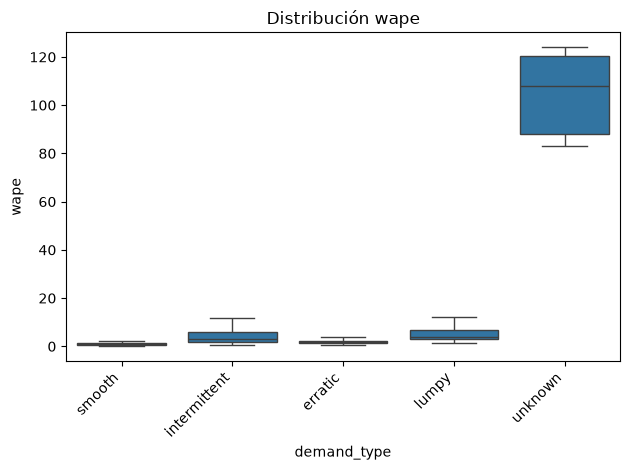

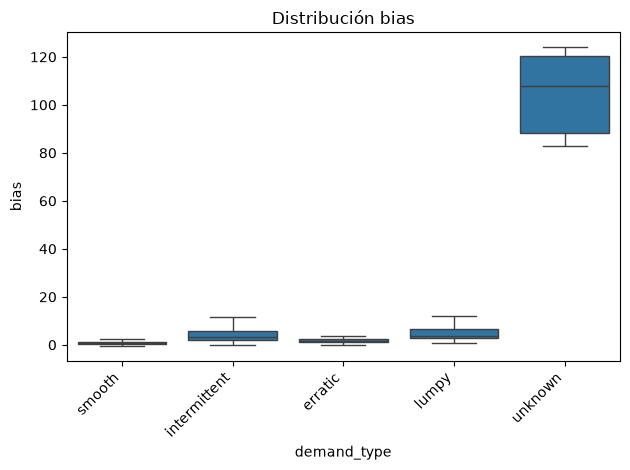

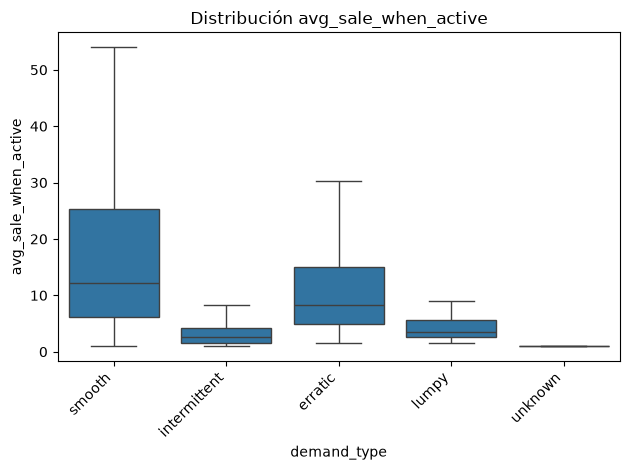

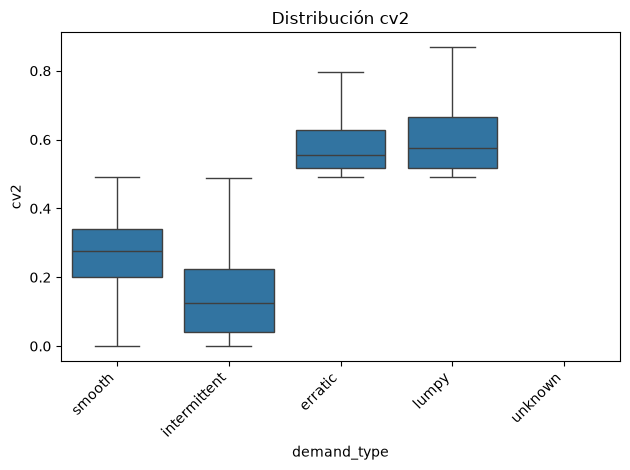

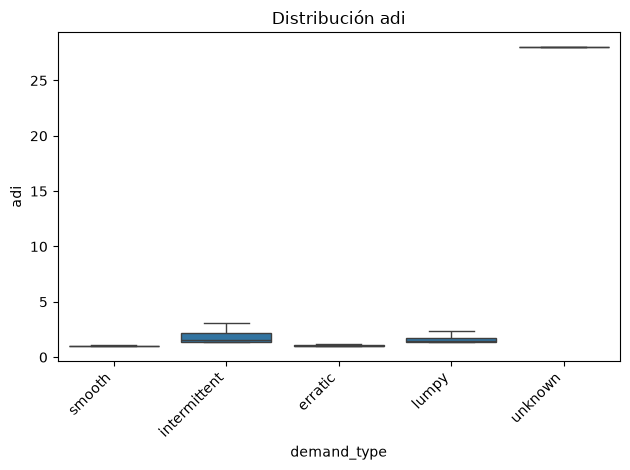

In [44]:
def plot_metric(df, by, metric='wape'):
    sns.boxplot(
        data=df.query("available_ratio >= 0.85"),
        x=by,
        y=metric,
        showfliers=False,
    )

    plt.title(f"Distribución {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in ['demand_type']:
    plot_metric(df_summary, col)
    plot_metric(df_summary, col, metric='bias')
    plot_metric(df_summary, col, metric='avg_sale_when_active')
    plot_metric(df_summary, col, metric='cv2')
    plot_metric(df_summary, col, metric='adi')

In [45]:
df_summary.query("available_ratio >= 0.85").groupby(['demand_type'])[['avg_sale_when_active','wape', 'bias','adi', 'cv2']].median().round(2)

,avg_sale_when_active,wape,bias,adi,cv2
demand_type,,,,,
erratic,8.26,1.66,1.59,1.00,0.56
intermittent,2.57,3.18,3.16,1.56,0.13
lumpy,3.52,3.92,3.89,1.47,0.58
smooth,12.21,0.90,0.84,1.00,0.27
unknown,1.00,108.00,108.00,28.00,NaN


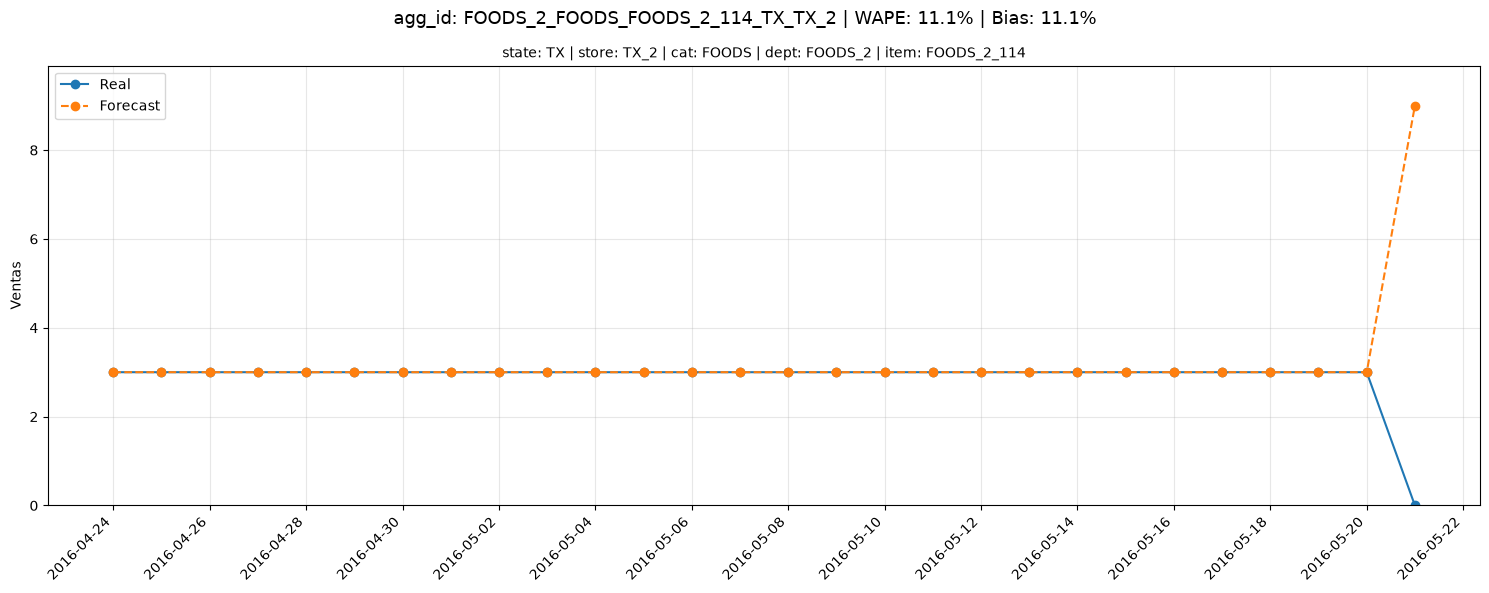

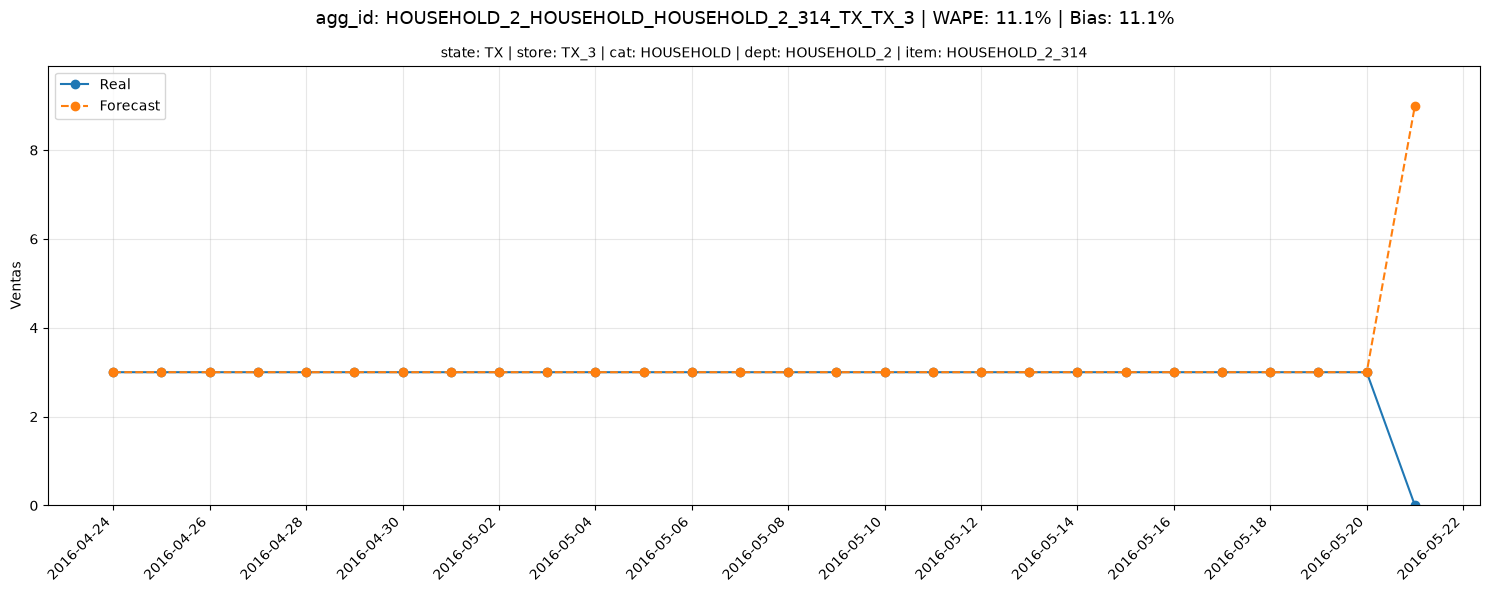

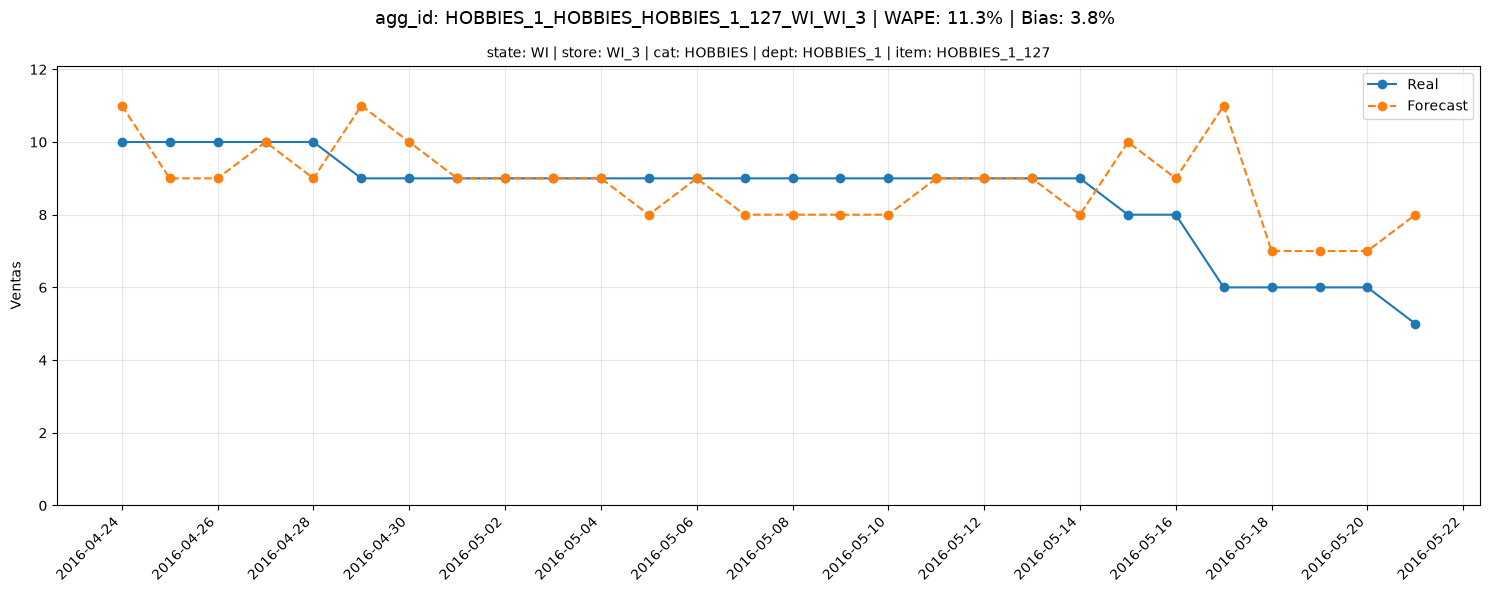

In [46]:
for id in df_summary['agg_id'].head(3):
    plot_agg_id_forecast(df, id)

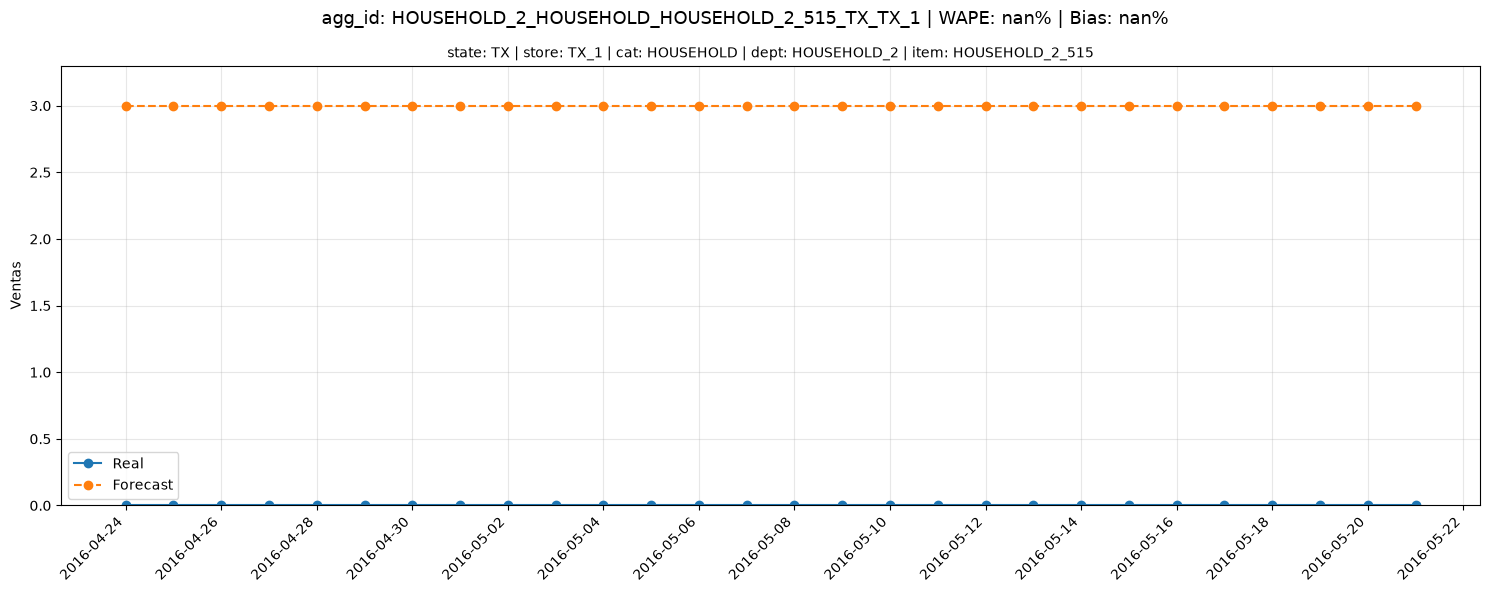

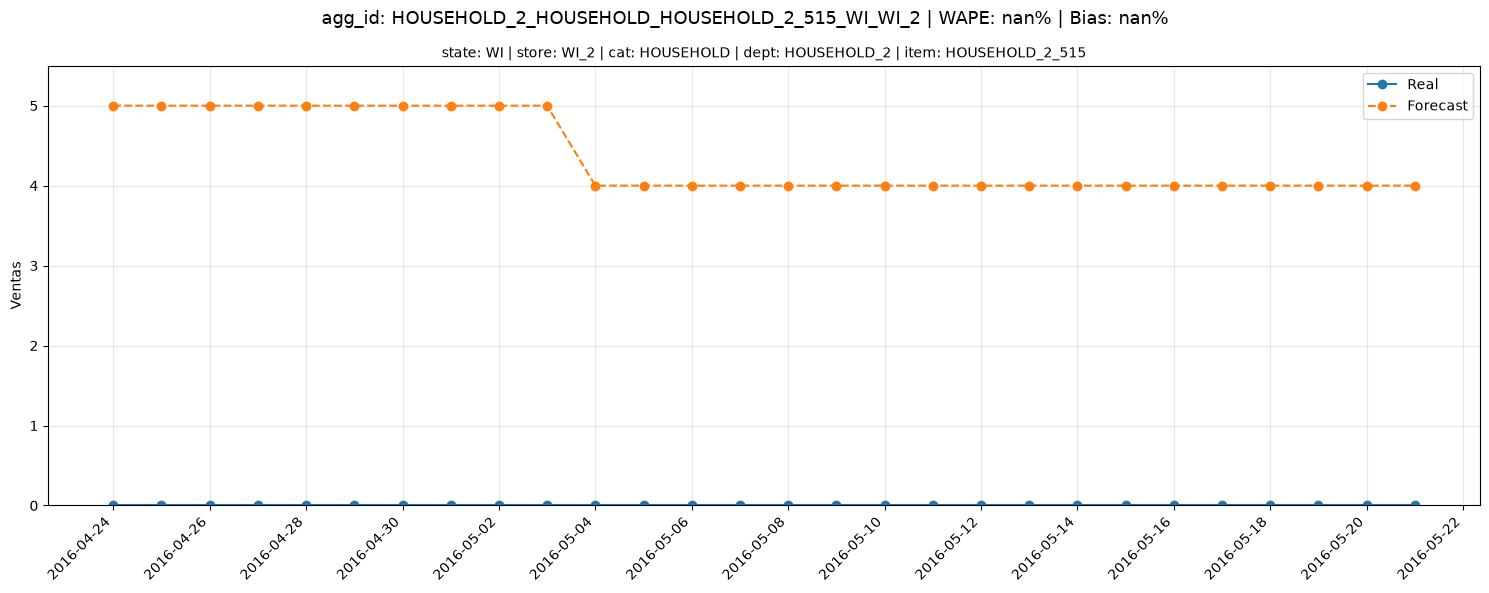

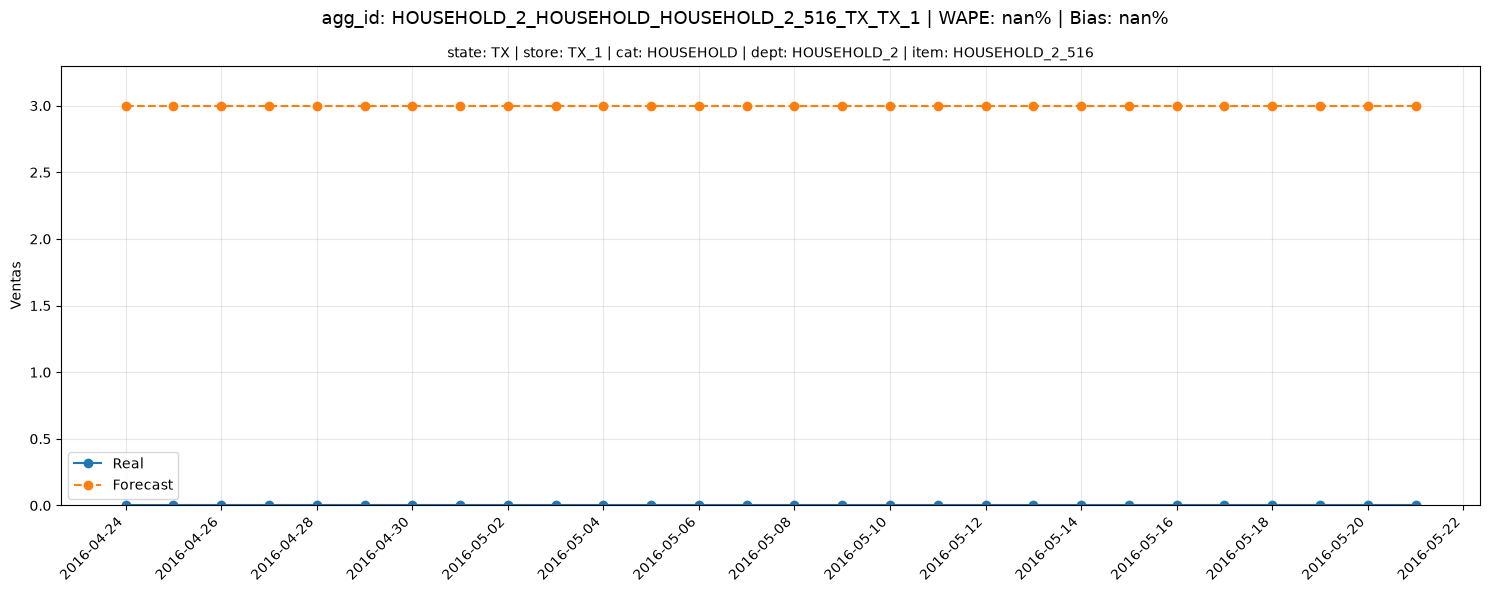

In [47]:
for id in df_summary['agg_id'].tail(3):
    plot_agg_id_forecast(df, id)

# Por grupo

In [48]:
df.head()

,agg_id,state_id,store_id,cat_id,dept_id,item_id,date,sales,forecast,error,abs_error
0,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-24,23,27,-4,4
1,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-25,21,29,-8,8
2,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-26,21,28,-7,7
3,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-27,21,27,-6,6
4,FOODS_1_FOODS_FOODS_1_001_CA_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2016-04-28,21,27,-6,6


In [49]:
df_summary_cat = (
    analyze_agg(df, ['cat_id','dept_id','item_id'])
).sort_values('wape')
df_summary_cat.head()

,cat_id,dept_id,item_id,n_obs,sales_sum,forecast_sum,rmse,first_sale,last_sale,available_periods,active_periods,avg_sale_when_active,adi,cv2,wape,bias,demand_type,available_ratio,active_ratio
702,FOODS,FOODS_3,FOODS_3_090,280,224226,300021,505.074086,2016-04-24,2016-05-21,280,280,800.807143,1.000000,0.664172,0.478263,0.338029,erratic,1.0,1.000000
839,FOODS,FOODS_3,FOODS_3_227,280,20659,27189,59.025963,2016-04-24,2016-05-21,280,278,74.312950,1.007194,0.867624,0.557917,0.316085,erratic,1.0,0.992857
2972,HOUSEHOLD,HOUSEHOLD_2,HOUSEHOLD_2_440,280,13986,18754,62.733222,2016-04-24,2016-05-21,280,264,52.977273,1.060606,4.786651,0.558416,0.340912,erratic,1.0,0.942857
1313,FOODS,FOODS_3,FOODS_3_702,280,60901,76885,159.833418,2016-04-24,2016-05-21,280,280,217.503571,1.000000,0.571014,0.571879,0.262459,erratic,1.0,1.000000
2805,HOUSEHOLD,HOUSEHOLD_2,HOUSEHOLD_2_273,280,2664,3764,8.327236,2016-04-24,2016-05-21,280,273,9.758242,1.025641,0.909397,0.586336,0.412913,erratic,1.0,0.975000
